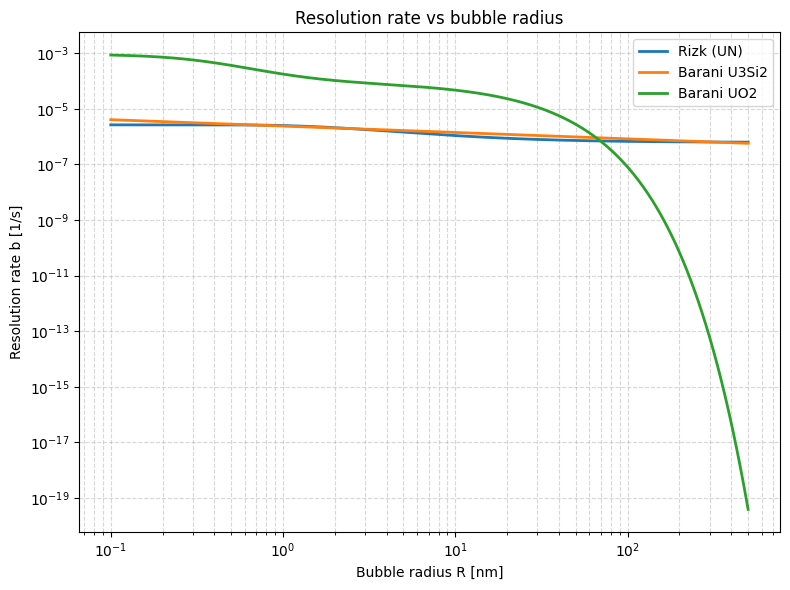


===== Resolution rate values =====

Rizk (UN):
  R_min = 1.000e-01 nm → b = 2.640e-06 s^-1
  R_mid = 7.079e+00 nm → b = 1.247e-06 s^-1
  R_max = 5.012e+02 nm → b = 6.305e-07 s^-1

Barani (U3Si2):
  R_min = 1.000e-01 nm → b = 4.054e-06 s^-1
  R_mid = 7.079e+00 nm → b = 1.525e-06 s^-1
  R_max = 5.012e+02 nm → b = 5.714e-07 s^-1

Barani (UO2):
  R_min = 1.000e-01 nm → b = 8.562e-04 s^-1
  R_mid = 7.079e+00 nm → b = 5.811e-05 s^-1
  R_max = 5.012e+02 nm → b = 3.877e-20 s^-1


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Parametri
# =========================
F = 1e19  # fission rate [m^-3 s^-1]

# Range R: 0.1 nm → 500 nm
R = np.logspace(-10, -6.3, 500)  # in metri (~1e-10 → ~5e-7)

# =========================
# 1. Rizk (UN)
# =========================
b0_rizk = 1e-25 * (2.64 - 2.02 * np.exp(-2.61e-9 / R))
b_rizk = b0_rizk * F

# =========================
# 2. Barani (U3Si2)
# =========================
b0_barani_si = 2.80e-25 * (5e-10 / R)**0.23
b_barani_si = b0_barani_si * F

# =========================
# 3. Barani (UO2)
# =========================
a = 9.49e-24
b0 = 9.18e-23
b1 = 7.07e7
c = 7.982e18
d = 3.71e16

b0_barani_uo2 = (
    a * np.exp(-b1 * R)
    + ((b0 - a) / (1 + c * R**2)) * np.exp(-d * R**2)
)

b_barani_uo2 = b0_barani_uo2 * F

# =========================
# Plot
# =========================
plt.figure(figsize=(8,6))

plt.loglog(R*1e9, b_rizk, label='Rizk (UN)', linewidth=2)
plt.loglog(R*1e9, b_barani_si, label='Barani U3Si2', linewidth=2)
plt.loglog(R*1e9, b_barani_uo2, label='Barani UO2', linewidth=2)

plt.xlabel('Bubble radius R [nm]')
plt.ylabel('Resolution rate b [1/s]')
plt.title('Resolution rate vs bubble radius')

plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# =========================
# Valori caratteristici
# =========================

# R minimo, massimo e medio (geometrico)
R_min = R[0]
R_max = R[-1]
R_mid = np.sqrt(R_min * R_max)  # media logaritmica (più corretta qui)

print("\n===== Resolution rate values =====")

def print_values(name, b_array):
    b_min = b_array[0]
    b_max = b_array[-1]
    
    # trova il valore più vicino a R_mid
    idx_mid = np.argmin(np.abs(R - R_mid))
    b_mid = b_array[idx_mid]
    
    print(f"\n{name}:")
    print(f"  R_min = {R_min*1e9:.3e} nm → b = {b_min:.3e} s^-1")
    print(f"  R_mid = {R_mid*1e9:.3e} nm → b = {b_mid:.3e} s^-1")
    print(f"  R_max = {R_max*1e9:.3e} nm → b = {b_max:.3e} s^-1")

# stampa per i tre modelli
print_values("Rizk (UN)", b_rizk)
print_values("Barani (U3Si2)", b_barani_si)
print_values("Barani (UO2)", b_barani_uo2)

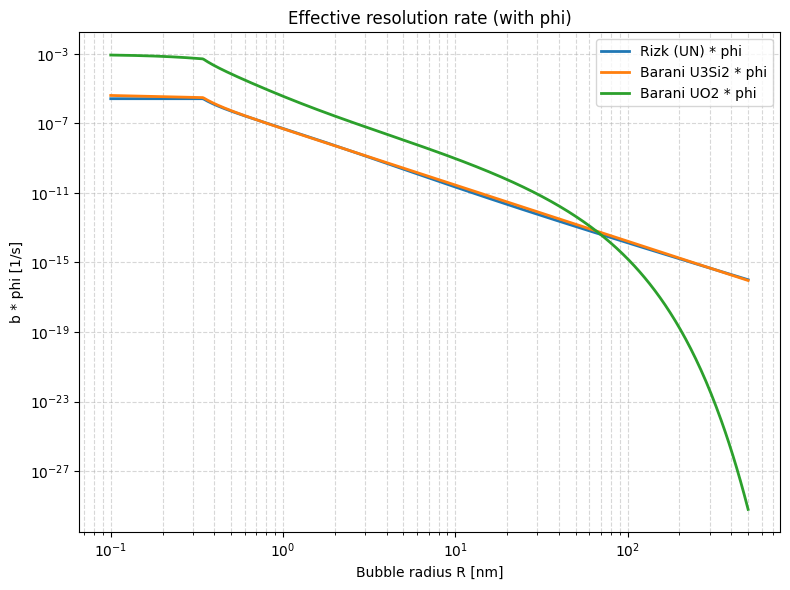


===== Resolution rate * phi =====

Rizk (UN):
  R_min = 1.000e-01 nm → b·phi = 2.640e-06 s^-1
  R_mid = 7.079e+00 nm → b·phi = 7.319e-11 s^-1
  R_max = 5.012e+02 nm → b·phi = 1.016e-16 s^-1

Barani (U3Si2):
  R_min = 1.000e-01 nm → b·phi = 4.054e-06 s^-1
  R_mid = 7.079e+00 nm → b·phi = 8.949e-11 s^-1
  R_max = 5.012e+02 nm → b·phi = 9.210e-17 s^-1

Barani (UO2):
  R_min = 1.000e-01 nm → b·phi = 8.562e-04 s^-1
  R_mid = 7.079e+00 nm → b·phi = 3.410e-09 s^-1
  R_max = 5.012e+02 nm → b·phi = 6.249e-30 s^-1


In [2]:
# =========================
# Phi e m(R)
# =========================

Omega_fg = 8.5e-29  # [m^3]

# numero medio di atomi nella bolla
m = (4/3) * np.pi * R**3 / Omega_fg
m_safe = np.maximum(m, 2.0)

# phi
phi = 1 / (m_safe - 1)

# =========================
# b * phi
# =========================
bphi_rizk = b_rizk * phi
bphi_barani_si = b_barani_si * phi
bphi_barani_uo2 = b_barani_uo2 * phi

plt.figure(figsize=(8,6))

plt.loglog(R*1e9, bphi_rizk, label='Rizk (UN) * phi', linewidth=2)
plt.loglog(R*1e9, bphi_barani_si, label='Barani U3Si2 * phi', linewidth=2)
plt.loglog(R*1e9, bphi_barani_uo2, label='Barani UO2 * phi', linewidth=2)

plt.xlabel('Bubble radius R [nm]')
plt.ylabel('b * phi [1/s]')
plt.title('Effective resolution rate (with phi)')

plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# =========================
# Valori caratteristici (b * phi)
# =========================

# R minimo, massimo e medio (geometrico)
R_min = R[0]
R_max = R[-1]
R_mid = np.sqrt(R_min * R_max)

print("\n===== Resolution rate * phi =====")

def print_values(name, bphi_array):
    b_min = bphi_array[0]
    b_max = bphi_array[-1]
    
    # indice del valore più vicino a R_mid
    idx_mid = np.argmin(np.abs(R - R_mid))
    b_mid = bphi_array[idx_mid]
    
    print(f"\n{name}:")
    print(f"  R_min = {R_min*1e9:.3e} nm → b·phi = {b_min:.3e} s^-1")
    print(f"  R_mid = {R_mid*1e9:.3e} nm → b·phi = {b_mid:.3e} s^-1")
    print(f"  R_max = {R_max*1e9:.3e} nm → b·phi = {b_max:.3e} s^-1")

# stampa
print_values("Rizk (UN)", bphi_rizk)
print_values("Barani (U3Si2)", bphi_barani_si)
print_values("Barani (UO2)", bphi_barani_uo2)

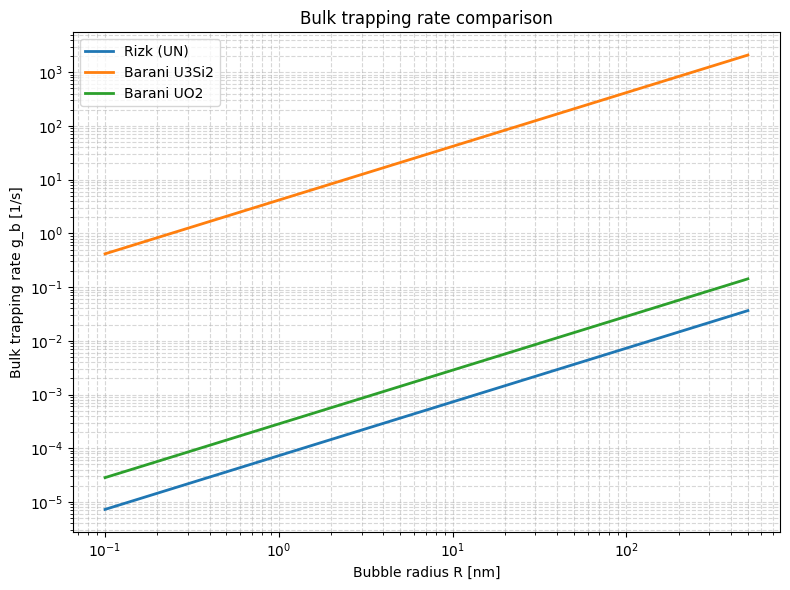


===== Bulk trapping rate =====

Rizk (UN):
  R_min = 1.000e-01 nm → g = 7.268e-06 s^-1
  R_mid = 7.079e+00 nm → g = 5.102e-04 s^-1
  R_max = 5.012e+02 nm → g = 3.643e-02 s^-1

Barani (U3Si2):
  R_min = 1.000e-01 nm → g = 4.154e-01 s^-1
  R_mid = 7.079e+00 nm → g = 2.916e+01 s^-1
  R_max = 5.012e+02 nm → g = 2.082e+03 s^-1

Barani (UO2):
  R_min = 1.000e-01 nm → g = 2.837e-05 s^-1
  R_mid = 7.079e+00 nm → g = 1.991e-03 s^-1
  R_max = 5.012e+02 nm → g = 1.422e-01 s^-1


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Parametri
# =========================

T = 1500            # temperatura [K]
F = 1e19            # fission rate [m^-3 s^-1]
N = 1e23            # concentrazione bolle [bub/m^3] (scegli tu!)

# Range R: 0.1 nm → 500 nm
R = np.logspace(-10, -6.3, 500)

# =========================
# 1. Rizk (UN)
# =========================

kB_eV = 8.617e-5

D1_rizk = 1.56e-3 * np.exp(-4.94 / (kB_eV * T))
D3_rizk = 1.85e-39 * F
D_rizk = D1_rizk + D3_rizk

g_rizk = 4 * np.pi * D_rizk * R * N

# =========================
# 2. Barani (U3Si2)
# =========================

kB_J = 1.38e-23

D_barani_si = 5.91e-6 * np.exp(-4.41e-19 / (kB_J * T))

g_barani_si = 4 * np.pi * D_barani_si * R * N

# =========================
# 3. Barani (UO2)
# =========================

D1 = 7.6e-10 * np.exp(-4.86e-19 / (kB_J * T))
D2 = 5.64e-25 * np.sqrt(F) * np.exp(-1.91e-19 / (kB_J * T))
D3 = 2.0e-40 * F

D_uo2 = D1 + D2 + D3

g_barani_uo2 = 4 * np.pi * D_uo2 * R * N

# =========================
# Plot
# =========================

plt.figure(figsize=(8,6))

plt.loglog(R*1e9, g_rizk, label='Rizk (UN)', linewidth=2)
plt.loglog(R*1e9, g_barani_si, label='Barani U3Si2', linewidth=2)
plt.loglog(R*1e9, g_barani_uo2, label='Barani UO2', linewidth=2)

plt.xlabel('Bubble radius R [nm]')
plt.ylabel('Bulk trapping rate g_b [1/s]')
plt.title('Bulk trapping rate comparison')

plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# =========================
# Valori caratteristici
# =========================

R_min = R[0]
R_max = R[-1]
R_mid = np.sqrt(R_min * R_max)

print("\n===== Bulk trapping rate =====")

def print_values(name, g_array):
    g_min = g_array[0]
    g_max = g_array[-1]
    
    idx_mid = np.argmin(np.abs(R - R_mid))
    g_mid = g_array[idx_mid]
    
    print(f"\n{name}:")
    print(f"  R_min = {R_min*1e9:.3e} nm → g = {g_min:.3e} s^-1")
    print(f"  R_mid = {R_mid*1e9:.3e} nm → g = {g_mid:.3e} s^-1")
    print(f"  R_max = {R_max*1e9:.3e} nm → g = {g_max:.3e} s^-1")

print_values("Rizk (UN)", g_rizk)
print_values("Barani (U3Si2)", g_barani_si)
print_values("Barani (UO2)", g_barani_uo2)

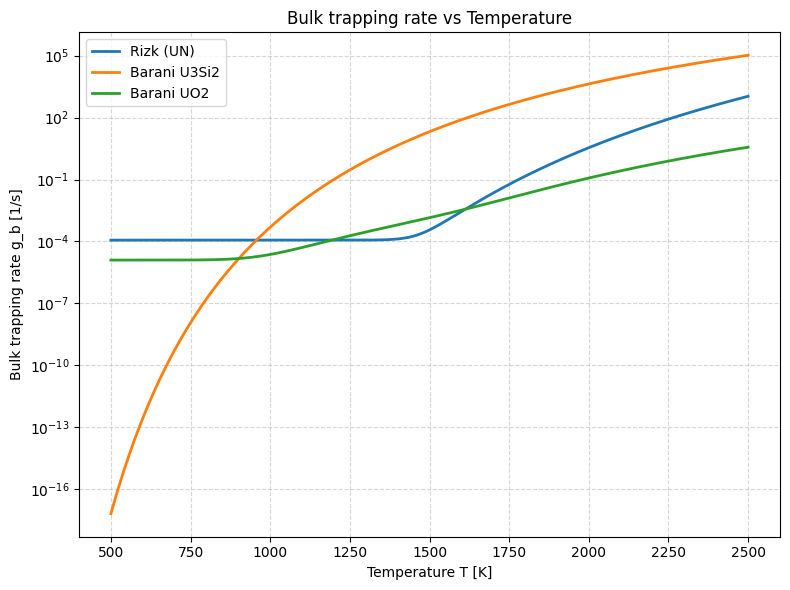


===== Bulk trapping rate vs T =====

Rizk (UN):
  T_min = 500.0 K → g = 1.162e-04 s^-1
  T_mid = 1500.0 K → g = 3.511e-04 s^-1
  T_max = 2500.0 K → g = 1.077e+03 s^-1

Barani (U3Si2):
  T_min = 500.0 K → g = 6.497e-18 s^-1
  T_mid = 1500.0 K → g = 2.019e+01 s^-1
  T_max = 2500.0 K → g = 1.043e+05 s^-1

Barani (UO2):
  T_min = 500.0 K → g = 1.257e-05 s^-1
  T_mid = 1500.0 K → g = 1.395e-03 s^-1
  T_max = 2500.0 K → g = 3.684e+00 s^-1


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Parametri
# =========================

F = 1e19          # fission rate [m^-3 s^-1]
R = 5e-9          # raggio bolla [m] (es: 5 nm)
N = 1e23          # concentrazione bolle [bub/m^3]

# Range temperatura
T = np.linspace(500, 2500, 500)   # [K]

# =========================
# 1. Rizk (UN)
# =========================

kB_eV = 8.617e-5

D1_rizk = 1.56e-3 * np.exp(-4.94 / (kB_eV * T))
D3_rizk = 1.85e-39 * F
D_rizk = D1_rizk + D3_rizk

g_rizk = 4 * np.pi * D_rizk * R * N

# =========================
# 2. Barani (U3Si2)
# =========================

kB_J = 1.38e-23

D_barani_si = 5.91e-6 * np.exp(-4.41e-19 / (kB_J * T))

g_barani_si = 4 * np.pi * D_barani_si * R * N

# =========================
# 3. Barani (UO2)
# =========================

D1 = 7.6e-10 * np.exp(-4.86e-19 / (kB_J * T))
D2 = 5.64e-25 * np.sqrt(F) * np.exp(-1.91e-19 / (kB_J * T))
D3 = 2.0e-40 * F

D_uo2 = D1 + D2 + D3

g_barani_uo2 = 4 * np.pi * D_uo2 * R * N

# =========================
# Plot
# =========================

plt.figure(figsize=(8,6))

plt.semilogy(T, g_rizk, label='Rizk (UN)', linewidth=2)
plt.semilogy(T, g_barani_si, label='Barani U3Si2', linewidth=2)
plt.semilogy(T, g_barani_uo2, label='Barani UO2', linewidth=2)

plt.xlabel('Temperature T [K]')
plt.ylabel('Bulk trapping rate g_b [1/s]')
plt.title('Bulk trapping rate vs Temperature')

plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# =========================
# Valori caratteristici
# =========================

T_min = T[0]
T_max = T[-1]
T_mid = 0.5 * (T_min + T_max)

print("\n===== Bulk trapping rate vs T =====")

def print_values(name, g_array):
    g_min = g_array[0]
    g_max = g_array[-1]
    
    idx_mid = np.argmin(np.abs(T - T_mid))
    g_mid = g_array[idx_mid]
    
    print(f"\n{name}:")
    print(f"  T_min = {T_min:.1f} K → g = {g_min:.3e} s^-1")
    print(f"  T_mid = {T_mid:.1f} K → g = {g_mid:.3e} s^-1")
    print(f"  T_max = {T_max:.1f} K → g = {g_max:.3e} s^-1")

print_values("Rizk (UN)", g_rizk)
print_values("Barani (U3Si2)", g_barani_si)
print_values("Barani (UO2)", g_barani_uo2)

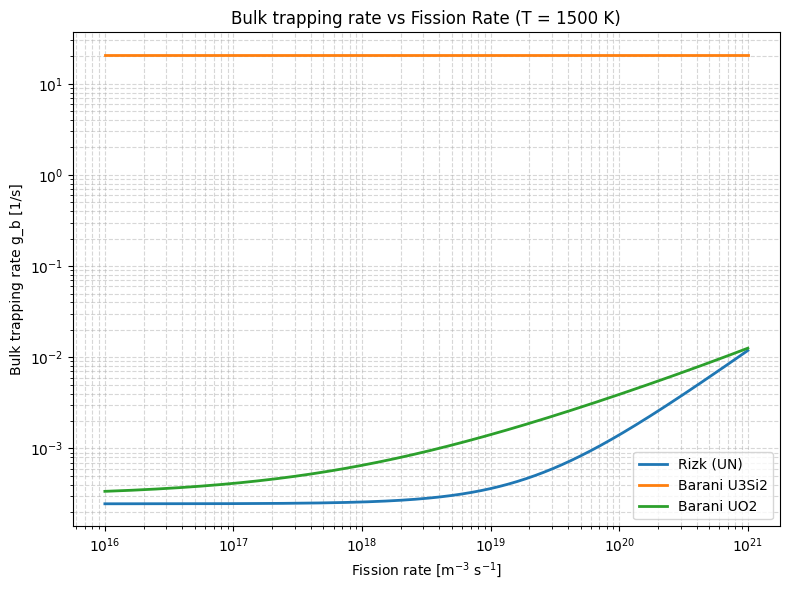


===== Bulk trapping rate vs F =====

Rizk (UN):
  F_min = 1.000e+16 → g = 2.473e-04 s^-1
  F_mid = 3.162e+18 → g = 2.835e-04 s^-1
  F_max = 1.000e+21 → g = 1.187e-02 s^-1

Barani (U3Si2):
  F_min = 1.000e+16 → g = 2.077e+01 s^-1
  F_mid = 3.162e+18 → g = 2.077e+01 s^-1
  F_max = 1.000e+21 → g = 2.077e+01 s^-1

Barani (UO2):
  F_min = 1.000e+16 → g = 3.386e-04 s^-1
  F_mid = 3.162e+18 → g = 9.238e-04 s^-1
  F_max = 1.000e+21 → g = 1.258e-02 s^-1


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Parametri
# =========================

T = 1500          # temperatura [K]
R = 5e-9          # raggio bolla [m]
N = 1e23          # concentrazione bolle [bub/m^3]

# Range fission rate
F = np.logspace(16, 21, 500)   # [m^-3 s^-1]

# =========================
# 1. Rizk (UN)
# =========================

kB_eV = 8.617e-5

D1_rizk = 1.56e-3 * np.exp(-4.94 / (kB_eV * T))
D3_rizk = 1.85e-39 * F
D_rizk = D1_rizk + D3_rizk

g_rizk = 4 * np.pi * D_rizk * R * N

# =========================
# 2. Barani (U3Si2)
# =========================

kB_J = 1.38e-23

D_barani_si = 5.91e-6 * np.exp(-4.41e-19 / (kB_J * T))


g_barani_si = np.full_like(F, 4 * np.pi * D_barani_si * R * N)

# =========================
# 3. Barani (UO2)
# =========================

D1 = 7.6e-10 * np.exp(-4.86e-19 / (kB_J * T))
D2 = 5.64e-25 * np.sqrt(F) * np.exp(-1.91e-19 / (kB_J * T))
D3 = 2.0e-40 * F

D_uo2 = D1 + D2 + D3

g_barani_uo2 = 4 * np.pi * D_uo2 * R * N

# =========================
# Plot
# =========================

plt.figure(figsize=(8,6))

plt.loglog(F, g_rizk, label='Rizk (UN)', linewidth=2)
plt.loglog(F, g_barani_si, label='Barani U3Si2', linewidth=2)
plt.loglog(F, g_barani_uo2, label='Barani UO2', linewidth=2)

plt.xlabel('Fission rate [m$^{-3}$ s$^{-1}$]')
plt.ylabel('Bulk trapping rate g_b [1/s]')
plt.title(f'Bulk trapping rate vs Fission Rate (T = {T} K)')

plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# =========================
# Valori caratteristici
# =========================

F_min = F[0]
F_max = F[-1]
F_mid = np.sqrt(F_min * F_max)

print("\n===== Bulk trapping rate vs F =====")

def print_values(name, g_array):
    g_min = g_array[0]
    g_max = g_array[-1]
    
    idx_mid = np.argmin(np.abs(F - F_mid))
    g_mid = g_array[idx_mid]
    
    print(f"\n{name}:")
    print(f"  F_min = {F_min:.3e} → g = {g_min:.3e} s^-1")
    print(f"  F_mid = {F_mid:.3e} → g = {g_mid:.3e} s^-1")
    print(f"  F_max = {F_max:.3e} → g = {g_max:.3e} s^-1")

print_values("Rizk (UN)", g_rizk)
print_values("Barani (U3Si2)", g_barani_si)
print_values("Barani (UO2)", g_barani_uo2)

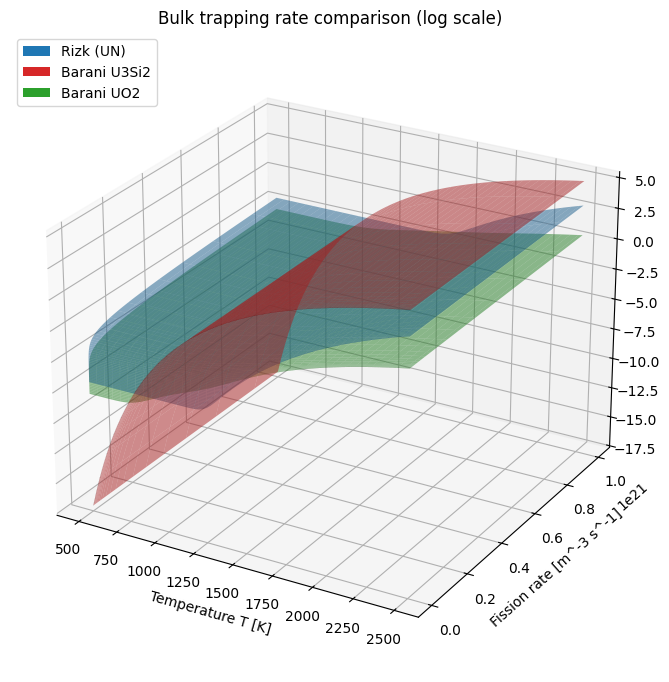

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import Patch

# =========================
# Parametri
# =========================

R = 5e-9
N = 1e23

T = np.linspace(500, 2500, 80)
F = np.logspace(16, 21, 80)

T_grid, F_grid = np.meshgrid(T, F)

# =========================
# 1. Rizk (UN)
# =========================

kB_eV = 8.617e-5

D1_rizk = 1.56e-3 * np.exp(-4.94 / (kB_eV * T_grid))
D3_rizk = 1.85e-39 * F_grid
D_rizk = D1_rizk + D3_rizk

g_rizk = 4 * np.pi * D_rizk * R * N

# =========================
# 2. Barani (U3Si2)
# =========================

kB_J = 1.38e-23

D_barani_si = 5.91e-6 * np.exp(-4.41e-19 / (kB_J * T_grid))
g_barani_si = 4 * np.pi * D_barani_si * R * N

# =========================
# 3. Barani (UO2)
# =========================

D1 = 7.6e-10 * np.exp(-4.86e-19 / (kB_J * T_grid))
D2 = 5.64e-25 * np.sqrt(F_grid) * np.exp(-1.91e-19 / (kB_J * T_grid))
D3 = 2.0e-40 * F_grid

D_uo2 = D1 + D2 + D3
g_barani_uo2 = 4 * np.pi * D_uo2 * R * N

# =========================
# LOG10 (con protezione)
# =========================

eps = 1e-30  # evita log(0)

g_rizk_log = np.log10(np.maximum(g_rizk, eps))
g_barani_si_log = np.log10(np.maximum(g_barani_si, eps))
g_barani_uo2_log = np.log10(np.maximum(g_barani_uo2, eps))

# =========================
# Plot 3D
# =========================

fig = plt.figure(figsize=(11,8))
ax = fig.add_subplot(111, projection='3d')

# Colori (più belli da paper)
blue = '#1f77b4'
red = '#d62728'
green = '#2ca02c'

# Superfici
ax.plot_surface(T_grid, F_grid, g_rizk_log, color=blue, alpha=0.5)
ax.plot_surface(T_grid, F_grid, g_barani_si_log, color=red, alpha=0.5)
ax.plot_surface(T_grid, F_grid, g_barani_uo2_log, color=green, alpha=0.5)

# Labels
ax.set_xlabel('Temperature T [K]')
ax.set_ylabel('Fission rate [m^-3 s^-1]')
ax.set_zlabel('log10(g_b) [1/s]', labelpad=15)

ax.set_title('Bulk trapping rate comparison (log scale)')

# Vista migliore
ax.view_init(elev=25, azim=-60)

# Legenda (proxy objects)
legend_elements = [
    Patch(facecolor=blue, label='Rizk (UN)'),
    Patch(facecolor=red, label='Barani U3Si2'),
    Patch(facecolor=green, label='Barani UO2')
]

ax.legend(handles=legend_elements, loc='upper left')

# Layout fix
plt.subplots_adjust(left=0.05, right=0.82, bottom=0.1, top=0.9)

plt.show()

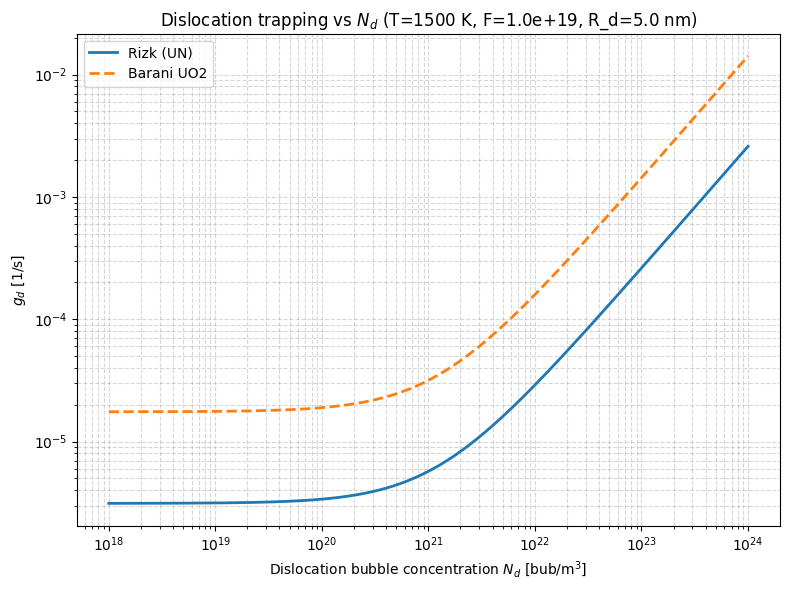

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Parametri fissati
# =========================

T = 1500          # [K]
F = 1e19          # [m^-3 s^-1]
R_d = 5e-9        # [m]

# Range Nd
N_d = np.logspace(18, 24, 500)  # [bub/m^3]

# =========================
# 1. Rizk (UN)
# =========================

kB_eV = 8.617e-5

# Diffusività
D1 = 1.56e-3 * np.exp(-4.94 / (kB_eV * T))
D3 = 1.85e-39 * F
D_g = D1 + D3

# Parametri UN
rho_d = 3.0e13
r_d = 3.46e-10
Z_d = 5.0

Gamma_d = 1 / np.sqrt(np.pi * rho_d)

# Termini
term_bubbles = 4 * np.pi * D_g * R_d * N_d

term_pipe = (
    (2 * np.pi * D_g) /
    (np.log(Gamma_d / (Z_d * r_d)) - 3/5)
) * (rho_d - 2 * R_d * N_d)

g_d_rizk = term_bubbles + term_pipe

# =========================
# 2. Barani (UO2)
# =========================

kB_J = 1.38e-23

D1 = 7.6e-10 * np.exp(-4.86e-19 / (kB_J * T))
D2 = 5.64e-25 * np.sqrt(F) * np.exp(-1.91e-19 / (kB_J * T))
D3 = 2.0e-40 * F

D_uo2 = D1 + D2 + D3

rho_d_uo2 = 4.0e13
r_d_uo2 = 1.925e-9

r_ws_d = 1 / np.sqrt(np.pi * rho_d_uo2)

term_bubbles_uo2 = 4 * np.pi * D_uo2 * R_d * N_d

term_pipe_uo2 = (
    (2 * np.pi * D_uo2) /
    (np.log(r_ws_d / r_d_uo2) - 3/5)
) * rho_d_uo2

g_d_uo2 = term_bubbles_uo2 + term_pipe_uo2



# =========================
# Plot
# =========================

plt.figure(figsize=(8,6))

plt.loglog(N_d, g_d_rizk, label='Rizk (UN)', linewidth=2)
plt.loglog(N_d, g_d_uo2, '--', label='Barani UO2', linewidth=2)

plt.xlabel('Dislocation bubble concentration $N_d$ [bub/m$^3$]')
plt.ylabel('$g_d$ [1/s]')
plt.title(f'Dislocation trapping vs $N_d$ (T={T} K, F={F:.1e}, R_d={R_d*1e9:.1f} nm)')

plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

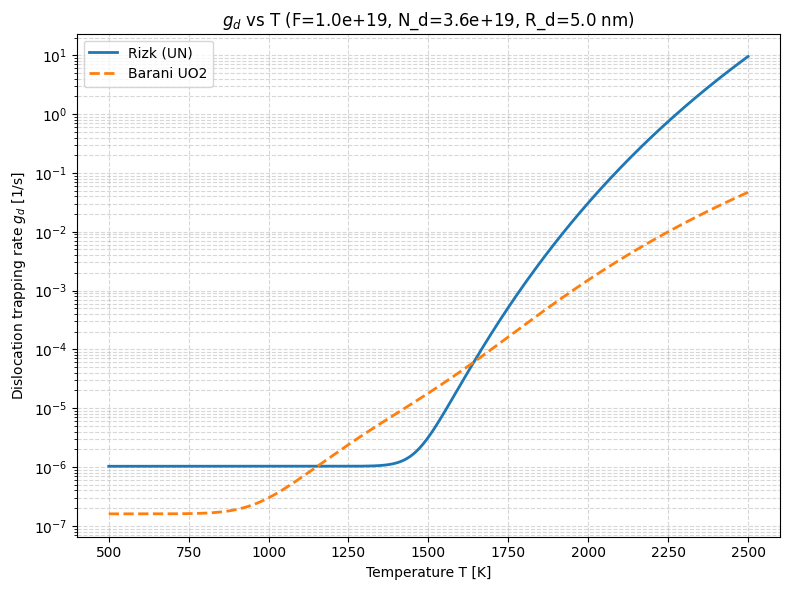


===== Dislocation trapping vs T =====

Rizk (UN):
  T_min = 500 K → g = 1.030e-06 s^-1
  T_mid = 1500 K → g = 3.111e-06 s^-1
  T_max = 2500 K → g = 9.545e+00 s^-1

Barani (UO2):
  T_min = 500 K → g = 1.599e-07 s^-1
  T_mid = 1500 K → g = 1.775e-05 s^-1
  T_max = 2500 K → g = 4.687e-02 s^-1


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Parametri fissati
# =========================

F = 1e19          # [m^-3 s^-1]
R_d = 5e-9        # [m]
N_d = 3.6*1e19        # [bub/m^3]

# Range temperatura
T = np.linspace(500, 2500, 500)

# =========================
# 1. Rizk (UN)
# =========================

kB_eV = 8.617e-5

D1 = 1.56e-3 * np.exp(-4.94 / (kB_eV * T))
D3 = 1.85e-39 * F
D_g = D1 + D3

rho_d = 3.0e13
r_d = 3.46e-10
Z_d = 5.0

Gamma_d = 1 / np.sqrt(np.pi * rho_d)

# Termine bubbles
term_bubbles = 4 * np.pi * D_g * R_d * N_d

# Termine pipe (con saturazione fisica)
available_length = np.maximum(rho_d - 2 * R_d * N_d, 0)

term_pipe = (
    (2 * np.pi * D_g) /
    (np.log(Gamma_d / (Z_d * r_d)) - 3/5)
) * available_length

g_d_rizk = term_bubbles + term_pipe

# =========================
# 2. Barani (UO2)
# =========================

kB_J = 1.38e-23

D1 = 7.6e-10 * np.exp(-4.86e-19 / (kB_J * T))
D2 = 5.64e-25 * np.sqrt(F) * np.exp(-1.91e-19 / (kB_J * T))
D3 = 2.0e-40 * F

D_uo2 = D1 + D2 + D3

rho_d_uo2 = 4.0e13
r_d_uo2 = 1.925e-9

r_ws_d = 1 / np.sqrt(np.pi * rho_d_uo2)

# bubbles
term_bubbles_uo2 = 4 * np.pi * D_uo2 * R_d * N_d

# pipe (costante rispetto a Nd, ma NON rispetto a T!)
term_pipe_uo2 = (
    (2 * np.pi * D_uo2) /
    (np.log(r_ws_d / r_d_uo2) - 3/5)
) * rho_d_uo2

g_d_uo2 = term_bubbles_uo2 + term_pipe_uo2

# =========================
# Plot
# =========================

plt.figure(figsize=(8,6))

plt.semilogy(T, g_d_rizk, label='Rizk (UN)', linewidth=2)
plt.semilogy(T, g_d_uo2, '--', label='Barani UO2', linewidth=2)

plt.xlabel('Temperature T [K]')
plt.ylabel('Dislocation trapping rate $g_d$ [1/s]')
plt.title(f'$g_d$ vs T (F={F:.1e}, N_d={N_d:.1e}, R_d={R_d*1e9:.1f} nm)')
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# =========================
# Valori caratteristici
# =========================

T_min = T[0]
T_max = T[-1]
T_mid = (T_min + T_max)/2

def print_values(name, g_array):
    g_min = g_array[0]
    g_max = g_array[-1]
    
    idx_mid = np.argmin(np.abs(T - T_mid))
    g_mid = g_array[idx_mid]
    
    print(f"\n{name}:")
    print(f"  T_min = {T_min:.0f} K → g = {g_min:.3e} s^-1")
    print(f"  T_mid = {T_mid:.0f} K → g = {g_mid:.3e} s^-1")
    print(f"  T_max = {T_max:.0f} K → g = {g_max:.3e} s^-1")

print("\n===== Dislocation trapping vs T =====")
print_values("Rizk (UN)", g_d_rizk)
print_values("Barani (UO2)", g_d_uo2)

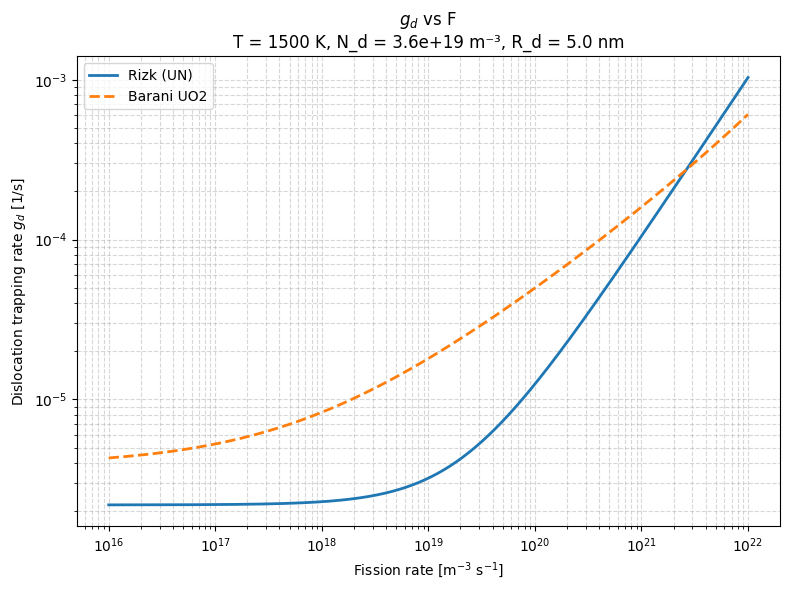


===== Dislocation trapping vs F =====

Rizk (UN):
  F_min = 1.000e+16 → g = 2.191e-06 s^-1
  F_mid = 1.000e+19 → g = 3.206e-06 s^-1
  F_max = 1.000e+22 → g = 1.032e-03 s^-1

Barani (UO2):
  F_min = 1.000e+16 → g = 4.307e-06 s^-1
  F_mid = 1.000e+19 → g = 1.794e-05 s^-1
  F_max = 1.000e+22 → g = 6.070e-04 s^-1


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Parametri fissati
# =========================

T = 1500          # [K]
R_d = 5e-9        # [m]
N_d = 3.6*1e19        # [bub/m^3]

# Range fission rate
F = np.logspace(16, 22, 500)   # [m^-3 s^-1]

# =========================
# 1. Rizk (UN)
# =========================

kB_eV = 8.617e-5

D1_rizk = 1.56e-3 * np.exp(-4.94 / (kB_eV * T))
D3_rizk = 1.85e-39 * F
D_rizk = D1_rizk + D3_rizk

rho_d = 3.0e13
r_d = 3.46e-10
Z_d = 5.0

Gamma_d = 1 / np.sqrt(np.pi * rho_d)

# Saturazione fisica
available_length = np.maximum(rho_d - 2 * R_d * N_d, 0)

# Termini
term_bubbles = 4 * np.pi * D_rizk * R_d * N_d

term_pipe = (
    (2 * np.pi * D_rizk) /
    (np.log(Gamma_d / (Z_d * r_d)) - 3/5)
) * available_length

g_d_rizk = term_bubbles + term_pipe

# =========================
# 2. Barani (UO2)
# =========================

kB_J = 1.38e-23

D1 = 7.6e-10 * np.exp(-4.86e-19 / (kB_J * T))
D2 = 5.64e-25 * np.sqrt(F) * np.exp(-1.91e-19 / (kB_J * T))
D3 = 2.0e-40 * F

D_uo2 = D1 + D2 + D3

rho_d_uo2 = 4.0e13
r_d_uo2 = 1.925e-9

r_ws_d = 1 / np.sqrt(np.pi * rho_d_uo2)

# Termini
term_bubbles_uo2 = 4 * np.pi * D_uo2 * R_d * N_d

term_pipe_uo2 = (
    (2 * np.pi * D_uo2) /
    (np.log(r_ws_d / r_d_uo2) - 3/5)
) * rho_d_uo2

g_d_uo2 = term_bubbles_uo2 + term_pipe_uo2

# =========================
# Plot
# =========================

plt.figure(figsize=(8,6))

plt.loglog(F, g_d_rizk, label='Rizk (UN)', linewidth=2)
plt.loglog(F, g_d_uo2, '--', label='Barani UO2', linewidth=2)

plt.xlabel('Fission rate [m$^{-3}$ s$^{-1}$]')
plt.ylabel('Dislocation trapping rate $g_d$ [1/s]')
plt.title(
    f'$g_d$ vs F\n'
    f'T = {T} K, N_d = {N_d:.1e} m⁻³, R_d = {R_d*1e9:.1f} nm'
)

plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# =========================
# Valori caratteristici
# =========================

F_min = F[0]
F_max = F[-1]
F_mid = np.sqrt(F_min * F_max)

def print_values(name, g_array):
    g_min = g_array[0]
    g_max = g_array[-1]
    
    idx_mid = np.argmin(np.abs(F - F_mid))
    g_mid = g_array[idx_mid]
    
    print(f"\n{name}:")
    print(f"  F_min = {F_min:.3e} → g = {g_min:.3e} s^-1")
    print(f"  F_mid = {F_mid:.3e} → g = {g_mid:.3e} s^-1")
    print(f"  F_max = {F_max:.3e} → g = {g_max:.3e} s^-1")

print("\n===== Dislocation trapping vs F =====")
print_values("Rizk (UN)", g_d_rizk)
print_values("Barani (UO2)", g_d_uo2)

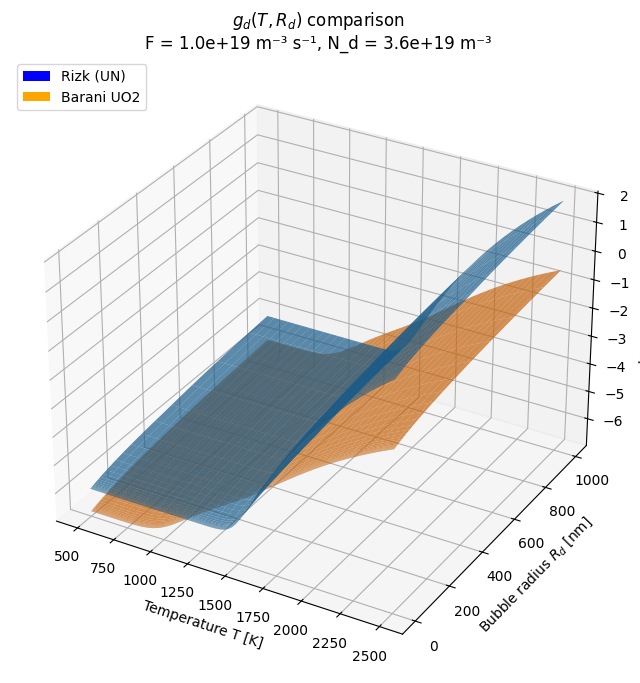

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# =========================
# Parametri fissati
# =========================

F = 1e19          # [m^-3 s^-1]
N_d = 3.6*1e19        # [bub/m^3]

# Range
T = np.linspace(500, 2500, 80)
R_d = np.logspace(-10, -6, 80)   # 0.1 nm → 1000 nm

T_grid, R_grid = np.meshgrid(T, R_d)

# =========================
# 1. Rizk (UN)
# =========================

kB_eV = 8.617e-5

D1 = 1.56e-3 * np.exp(-4.94 / (kB_eV * T_grid))
D3 = 1.85e-39 * F
D_g = D1 + D3

rho_d = 3.0e13
r_d = 3.46e-10
Z_d = 5.0

Gamma_d = 1 / np.sqrt(np.pi * rho_d)

# Saturazione
available_length = np.maximum(rho_d - 2 * R_grid * N_d, 0)

term_bubbles = 4 * np.pi * D_g * R_grid * N_d

term_pipe = (
    (2 * np.pi * D_g) /
    (np.log(Gamma_d / (Z_d * r_d)) - 3/5)
) * available_length

g_rizk = term_bubbles + term_pipe

# =========================
# 2. Barani (UO2)
# =========================

kB_J = 1.38e-23

D1 = 7.6e-10 * np.exp(-4.86e-19 / (kB_J * T_grid))
D2 = 5.64e-25 * np.sqrt(F) * np.exp(-1.91e-19 / (kB_J * T_grid))
D3 = 2.0e-40 * F

D_uo2 = D1 + D2 + D3

rho_d_uo2 = 4.0e13
r_d_uo2 = 1.925e-9

r_ws_d = 1 / np.sqrt(np.pi * rho_d_uo2)

term_bubbles_uo2 = 4 * np.pi * D_uo2 * R_grid * N_d

term_pipe_uo2 = (
    (2 * np.pi * D_uo2) /
    (np.log(r_ws_d / r_d_uo2) - 3/5)
) * rho_d_uo2

g_uo2 = term_bubbles_uo2 + term_pipe_uo2

# =========================
# LOG SCALE
# =========================

g_rizk_log = np.log10(g_rizk)
g_uo2_log = np.log10(g_uo2)

# =========================
# Plot 3D
# =========================

fig = plt.figure(figsize=(11,8))
ax = fig.add_subplot(111, projection='3d')

# UN
surf1 = ax.plot_surface(T_grid, R_grid*1e9, g_rizk_log,
                        alpha=0.7)

# UO2
surf2 = ax.plot_surface(T_grid, R_grid*1e9, g_uo2_log,
                        alpha=0.7)

ax.set_xlabel('Temperature T [K]')
ax.set_ylabel('Bubble radius $R_d$ [nm]')
ax.set_zlabel('log10($g_d$) [1/s]')

ax.set_title(
    f'$g_d(T, R_d)$ comparison\n'
    f'F = {F:.1e} m⁻³ s⁻¹, N_d = {N_d:.1e} m⁻³'
)

# =========================
# LEGENDA (manuale)
# =========================

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='blue', label='Rizk (UN)'),
    Patch(facecolor='orange', label='Barani UO2')
]
ax.legend(handles=legend_elements, loc='upper left')

plt.subplots_adjust(left=0.05, right=0.85)
plt.show()

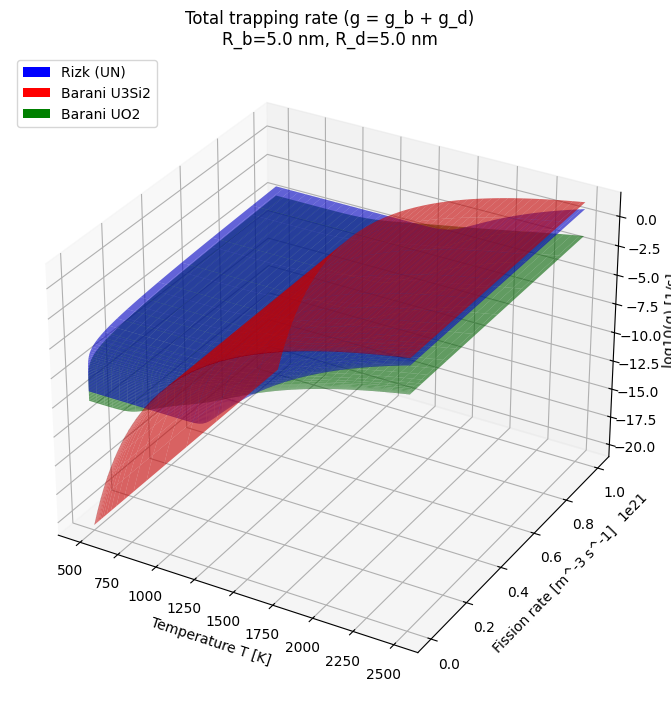


===== Total trapping rate g (g_b + g_d) =====

Rizk (UN):
  (T_min, F_min) = (500 K, 1.0e+16) → g = 1.072e-09 s^-1
  (T_mid, F_mid) = (1500 K, 3.2e+18) → g = 3.453e-06 s^-1
  (T_max, F_max) = (2500 K, 1.0e+21) → g = 9.933e+00 s^-1

Barani (U3Si2):
  (T_min, F_min) = (500 K, 1.0e+16) → g = 2.339e-21 s^-1
  (T_mid, F_mid) = (1500 K, 3.2e+18) → g = 8.936e-03 s^-1
  (T_max, F_max) = (2500 K, 1.0e+21) → g = 3.755e+01 s^-1

Barani (UO2):
  (T_min, F_min) = (500 K, 1.0e+16) → g = 1.644e-10 s^-1
  (T_mid, F_mid) = (1500 K, 3.2e+18) → g = 1.333e-05 s^-1
  (T_max, F_max) = (2500 K, 1.0e+21) → g = 5.341e-02 s^-1


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# =========================
# Parametri fissati
# =========================

R_b = 5e-9        # raggio bolla [m]
R_d = 5e-9        # raggio dislocazioni [m]

# Dislocazioni
rho_d_UN = 3.0e13
rho_d_UO2 = 4.0e13

# Costante iniziale Rizk
K = 1.2e6
N_d = K * rho_d_UN   # inizializzazione fisica

# =========================
# Range T e F
# =========================

T = np.linspace(500, 2500, 80)
F = np.logspace(16, 21, 80)

T_grid, F_grid = np.meshgrid(T, F)

# =========================
# 1. Rizk (UN)
# =========================

kB_eV = 8.617e-5

D1_rizk = 1.56e-3 * np.exp(-4.94 / (kB_eV * T_grid))
D3_rizk = 1.85e-39 * F_grid
D_rizk = D1_rizk + D3_rizk

# Bulk
g_b_rizk = 4 * np.pi * D_rizk * R_b * N_d

# Dislocation
r_d = 3.46e-10
Z_d = 5.0
Gamma_d = 1 / np.sqrt(np.pi * rho_d_UN)

available_length = np.maximum(rho_d_UN - 2 * R_d * N_d, 0)

g_d_rizk = (
    4 * np.pi * D_rizk * R_d * N_d
    + (2 * np.pi * D_rizk) /
      (np.log(Gamma_d / (Z_d * r_d)) - 3/5)
      * available_length
)

g_rizk = g_b_rizk + g_d_rizk

# =========================
# 2. Barani (U3Si2)
# =========================

kB_J = 1.38e-23

D_barani_si = 5.91e-6 * np.exp(-4.41e-19 / (kB_J * T_grid))

g_barani_si = 4 * np.pi * D_barani_si * R_b * N_d

# =========================
# 3. Barani (UO2)
# =========================

D1 = 7.6e-10 * np.exp(-4.86e-19 / (kB_J * T_grid))
D2 = 5.64e-25 * np.sqrt(F_grid) * np.exp(-1.91e-19 / (kB_J * T_grid))
D3 = 2.0e-40 * F_grid

D_uo2 = D1 + D2 + D3

# Bulk
g_b_uo2 = 4 * np.pi * D_uo2 * R_b * N_d

# Dislocation
r_d_uo2 = 1.925e-9
r_ws_d = 1 / np.sqrt(np.pi * rho_d_UO2)

g_d_uo2 = (
    4 * np.pi * D_uo2 * R_d * N_d
    + (2 * np.pi * D_uo2) /
      (np.log(r_ws_d / r_d_uo2) - 3/5)
      * rho_d_UO2
)

g_uo2 = g_b_uo2 + g_d_uo2

# =========================
# Log scala
# =========================

g_rizk_log = np.log10(g_rizk)
g_barani_si_log = np.log10(g_barani_si)
g_uo2_log = np.log10(g_uo2)

# =========================
# Plot 3D
# =========================

fig = plt.figure(figsize=(11,8))
ax = fig.add_subplot(111, projection='3d')

surf1 = ax.plot_surface(T_grid, F_grid, g_rizk_log, color='blue', alpha=0.6)
surf2 = ax.plot_surface(T_grid, F_grid, g_barani_si_log, color='red', alpha=0.6)
surf3 = ax.plot_surface(T_grid, F_grid, g_uo2_log, color='green', alpha=0.6)

ax.set_xlabel('Temperature T [K]')
ax.set_ylabel('Fission rate [m^-3 s^-1]')
ax.set_zlabel('log10(g) [1/s]')

ax.set_title(
    f'Total trapping rate (g = g_b + g_d)\n'
    f'R_b={R_b*1e9:.1f} nm, R_d={R_d*1e9:.1f} nm'
)

# Legenda
legend_elements = [
    Patch(facecolor='blue', label='Rizk (UN)'),
    Patch(facecolor='red', label='Barani U3Si2'),
    Patch(facecolor='green', label='Barani UO2')
]
ax.legend(handles=legend_elements, loc='upper left')

# Margini per non tagliare label
plt.subplots_adjust(left=0.05, right=0.82, bottom=0.1, top=0.9)

plt.show()

# =========================
# Valori caratteristici
# =========================

T_min, T_max = T[0], T[-1]
F_min, F_max = F[0], F[-1]

T_mid = (T_min + T_max) / 2
F_mid = np.sqrt(F_min * F_max)

def find_index(arr, value):
    return np.argmin(np.abs(arr - value))

# Indici
iT_min = find_index(T, T_min)
iT_mid = find_index(T, T_mid)
iT_max = find_index(T, T_max)

iF_min = find_index(F, F_min)
iF_mid = find_index(F, F_mid)
iF_max = find_index(F, F_max)

print("\n===== Total trapping rate g (g_b + g_d) =====")

def print_values(name, g):
    print(f"\n{name}:")
    
    print(f"  (T_min, F_min) = ({T_min:.0f} K, {F_min:.1e}) → g = {g[iF_min, iT_min]:.3e} s^-1")
    print(f"  (T_mid, F_mid) = ({T_mid:.0f} K, {F_mid:.1e}) → g = {g[iF_mid, iT_mid]:.3e} s^-1")
    print(f"  (T_max, F_max) = ({T_max:.0f} K, {F_max:.1e}) → g = {g[iF_max, iT_max]:.3e} s^-1")

print_values("Rizk (UN)", g_rizk)
print_values("Barani (U3Si2)", g_barani_si)
print_values("Barani (UO2)", g_uo2)

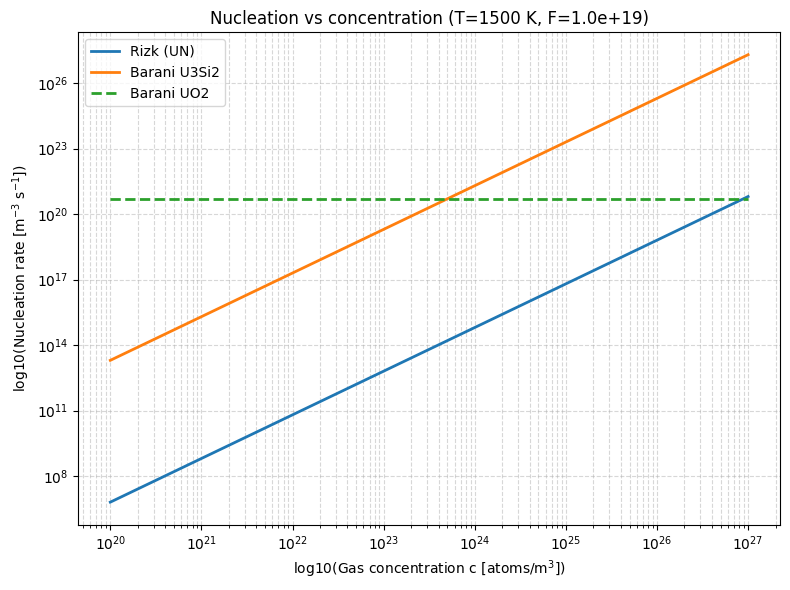


===== Nucleation vs c =====

Rizk (UN):
  c_min = 1.000e+20 → ν = 6.391e+06
  c_mid = 3.162e+23 → ν = 6.188e+13
  c_max = 1.000e+27 → ν = 6.391e+20

Barani (U3Si2):
  c_min = 1.000e+20 → ν = 2.002e+13
  c_mid = 3.162e+23 → ν = 1.938e+20
  c_max = 1.000e+27 → ν = 2.002e+27

Barani (UO2):
  c_min = 1.000e+20 → ν = 5.000e+20
  c_mid = 3.162e+23 → ν = 5.000e+20
  c_max = 1.000e+27 → ν = 5.000e+20


In [12]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Parametri fissati
# =========================

T = 1500            # [K]
F = 1e19            # [m^-3 s^-1]

# Range concentrazione gas
c = np.logspace(20, 27, 500)   # [atomi/m^3]

# =========================
# 1. Rizk (UN)
# =========================

kB_eV = 8.617e-5

# Diffusività
D1 = 1.56e-3 * np.exp(-4.94 / (kB_eV * T))
D3 = 1.85e-39 * F
D_g = D1 + D3

# Costanti
f_n_rizk = 1e-6
Omega_fg = 8.5e-29

nu_rizk = 8 * np.pi * f_n_rizk * D_g * (Omega_fg)**(1/3) * c**2

# =========================
# 2. Barani (U3Si2)
# =========================

kB_J = 1.38e-23

D_barani = 5.91e-6 * np.exp(-4.41e-19 / (kB_J * T))

f_n_barani = 1e-4
R_sg = 2.41e-10

nu_barani_si = 8 * np.pi * D_barani * R_sg * f_n_barani * c**2

# =========================
# 3. Barani (UO2)
# =========================

h = 25

# indipendente da c
nu_barani_uo2 = np.full_like(c, h * 2 * F)

# =========================
# Plot
# =========================

plt.figure(figsize=(8,6))

plt.loglog(c, nu_rizk, label='Rizk (UN)', linewidth=2)
plt.loglog(c, nu_barani_si, label='Barani U3Si2', linewidth=2)
plt.loglog(c, nu_barani_uo2, '--', label='Barani UO2', linewidth=2)

plt.xlabel('log10(Gas concentration c [atoms/m$^3$])')
plt.ylabel('log10(Nucleation rate [m$^{-3}$ s$^{-1}$])')
plt.title(f'Nucleation vs concentration (T={T} K, F={F:.1e})')

plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# =========================
# Valori caratteristici
# =========================

c_min = c[0]
c_max = c[-1]
c_mid = np.sqrt(c_min * c_max)

def print_values(name, nu_array):
    nu_min = nu_array[0]
    nu_max = nu_array[-1]
    
    idx_mid = np.argmin(np.abs(c - c_mid))
    nu_mid = nu_array[idx_mid]
    
    print(f"\n{name}:")
    print(f"  c_min = {c_min:.3e} → ν = {nu_min:.3e}")
    print(f"  c_mid = {c_mid:.3e} → ν = {nu_mid:.3e}")
    print(f"  c_max = {c_max:.3e} → ν = {nu_max:.3e}")

print("\n===== Nucleation vs c =====")
print_values("Rizk (UN)", nu_rizk)
print_values("Barani (U3Si2)", nu_barani_si)
print_values("Barani (UO2)", nu_barani_uo2)

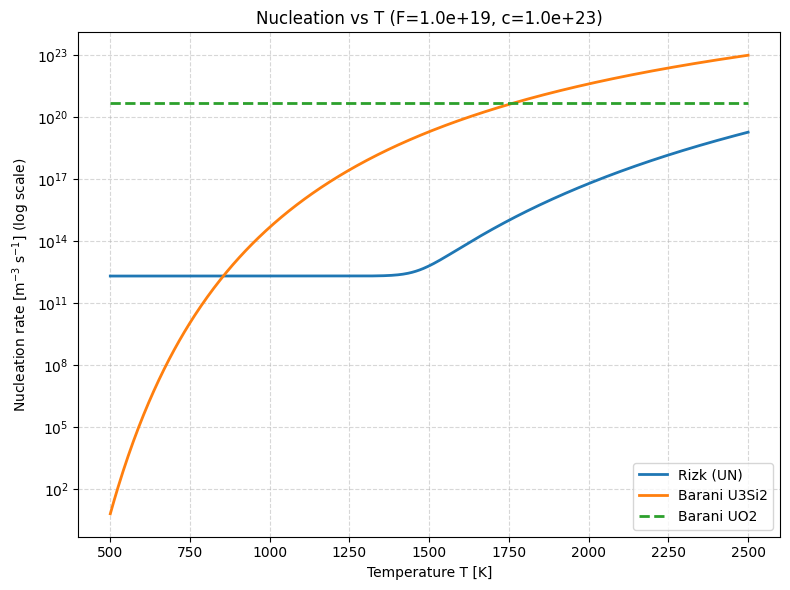


===== Nucleation vs T =====

Rizk (UN):
  T_min = 500 K → ν = 2.044e+12
  T_mid = 1500 K → ν = 6.175e+12
  T_max = 2500 K → ν = 1.895e+19

Barani (U3Si2):
  T_min = 500 K → ν = 6.263e+00
  T_mid = 1500 K → ν = 1.946e+19
  T_max = 2500 K → ν = 1.006e+23

Barani (UO2):
  T_min = 500 K → ν = 5.000e+20
  T_mid = 1500 K → ν = 5.000e+20
  T_max = 2500 K → ν = 5.000e+20


In [13]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Parametri fissati
# =========================

F = 1e19              # [m^-3 s^-1]
c = 1e23              # [atomi/m^3]

# Range temperatura
T = np.linspace(500, 2500, 500)

# =========================
# 1. Rizk (UN)
# =========================

kB_eV = 8.617e-5

D1 = 1.56e-3 * np.exp(-4.94 / (kB_eV * T))
D3 = 1.85e-39 * F
D_g = D1 + D3

f_n_rizk = 1e-6
Omega_fg = 8.5e-29

nu_rizk = 8 * np.pi * f_n_rizk * D_g * (Omega_fg)**(1/3) * c**2

# =========================
# 2. Barani (U3Si2)
# =========================

kB_J = 1.38e-23

D_barani = 5.91e-6 * np.exp(-4.41e-19 / (kB_J * T))

f_n_barani = 1e-4
R_sg = 2.41e-10

nu_barani_si = 8 * np.pi * D_barani * R_sg * f_n_barani * c**2

# =========================
# 3. Barani (UO2)
# =========================

h = 25

# indipendente da T
nu_barani_uo2 = np.full_like(T, h * 2 * F)

# =========================
# Plot
# =========================

plt.figure(figsize=(8,6))

plt.semilogy(T, nu_rizk, label='Rizk (UN)', linewidth=2)
plt.semilogy(T, nu_barani_si, label='Barani U3Si2', linewidth=2)
plt.semilogy(T, nu_barani_uo2, '--', label='Barani UO2', linewidth=2)

plt.xlabel('Temperature T [K]')
plt.ylabel('Nucleation rate [m$^{-3}$ s$^{-1}$] (log scale)')
plt.title(f'Nucleation vs T (F={F:.1e}, c={c:.1e})')

plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# =========================
# Valori caratteristici
# =========================

T_min = T[0]
T_max = T[-1]
T_mid = (T_min + T_max)/2

def print_values(name, nu_array):
    nu_min = nu_array[0]
    nu_max = nu_array[-1]
    
    idx_mid = np.argmin(np.abs(T - T_mid))
    nu_mid = nu_array[idx_mid]
    
    print(f"\n{name}:")
    print(f"  T_min = {T_min:.0f} K → ν = {nu_min:.3e}")
    print(f"  T_mid = {T_mid:.0f} K → ν = {nu_mid:.3e}")
    print(f"  T_max = {T_max:.0f} K → ν = {nu_max:.3e}")

print("\n===== Nucleation vs T =====")
print_values("Rizk (UN)", nu_rizk)
print_values("Barani (U3Si2)", nu_barani_si)
print_values("Barani (UO2)", nu_barani_uo2)

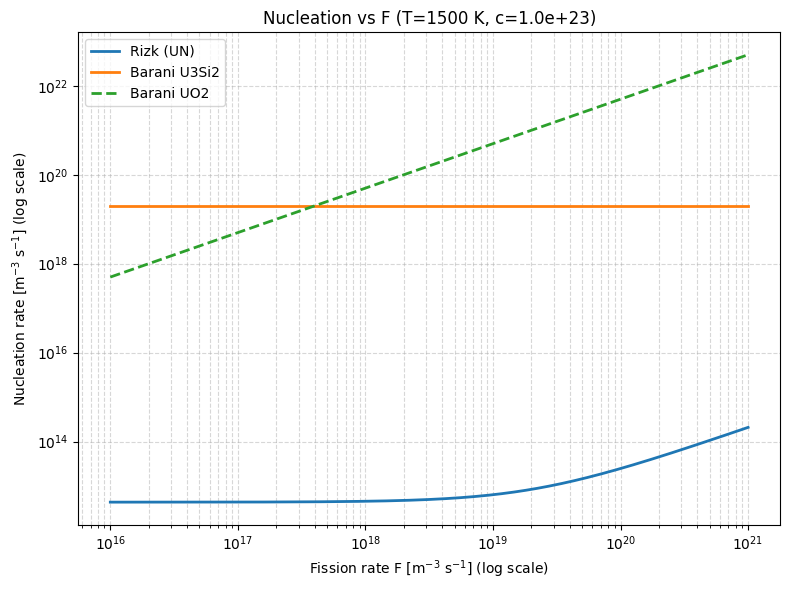


===== Nucleation vs F =====

Rizk (UN):
  F_min = 1.000e+16 → ν = 4.349e+12
  F_mid = 3.162e+18 → ν = 4.986e+12
  F_max = 1.000e+21 → ν = 2.088e+14

Barani (U3Si2):
  F_min = 1.000e+16 → ν = 2.002e+19
  F_mid = 3.162e+18 → ν = 2.002e+19
  F_max = 1.000e+21 → ν = 2.002e+19

Barani (UO2):
  F_min = 1.000e+16 → ν = 5.000e+17
  F_mid = 3.162e+18 → ν = 1.563e+20
  F_max = 1.000e+21 → ν = 5.000e+22


In [14]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Parametri fissati
# =========================

T = 1500            # [K]
c = 1e23            # [atomi/m^3]

# Range fission rate
F = np.logspace(16, 21, 500)   # [m^-3 s^-1]

# =========================
# 1. Rizk (UN)
# =========================

kB_eV = 8.617e-5

D1 = 1.56e-3 * np.exp(-4.94 / (kB_eV * T))
D3 = 1.85e-39 * F
D_g = D1 + D3

f_n_rizk = 1e-6
Omega_fg = 8.5e-29

nu_rizk = 8 * np.pi * f_n_rizk * D_g * (Omega_fg)**(1/3) * c**2

# =========================
# 2. Barani (U3Si2)
# =========================

kB_J = 1.38e-23

D_barani = 5.91e-6 * np.exp(-4.41e-19 / (kB_J * T))

f_n_barani = 1e-4
R_sg = 2.41e-10

# indipendente da F → array costante
nu_barani_si = np.full_like(F, 8 * np.pi * D_barani * R_sg * f_n_barani * c**2)

# =========================
# 3. Barani (UO2)
# =========================

h = 25

nu_barani_uo2 = 2 * h * F   # lineare in F

# =========================
# Plot
# =========================

plt.figure(figsize=(8,6))

plt.loglog(F, nu_rizk, label='Rizk (UN)', linewidth=2)
plt.loglog(F, nu_barani_si, label='Barani U3Si2', linewidth=2)
plt.loglog(F, nu_barani_uo2, '--', label='Barani UO2', linewidth=2)

plt.xlabel('Fission rate F [m$^{-3}$ s$^{-1}$] (log scale)')
plt.ylabel('Nucleation rate [m$^{-3}$ s$^{-1}$] (log scale)')
plt.title(f'Nucleation vs F (T={T} K, c={c:.1e})')

plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# =========================
# Valori caratteristici
# =========================

F_min = F[0]
F_max = F[-1]
F_mid = np.sqrt(F_min * F_max)

def print_values(name, nu_array):
    nu_min = nu_array[0]
    nu_max = nu_array[-1]
    
    idx_mid = np.argmin(np.abs(F - F_mid))
    nu_mid = nu_array[idx_mid]
    
    print(f"\n{name}:")
    print(f"  F_min = {F_min:.3e} → ν = {nu_min:.3e}")
    print(f"  F_mid = {F_mid:.3e} → ν = {nu_mid:.3e}")
    print(f"  F_max = {F_max:.3e} → ν = {nu_max:.3e}")

print("\n===== Nucleation vs F =====")
print_values("Rizk (UN)", nu_rizk)
print_values("Barani (U3Si2)", nu_barani_si)
print_values("Barani (UO2)", nu_barani_uo2)

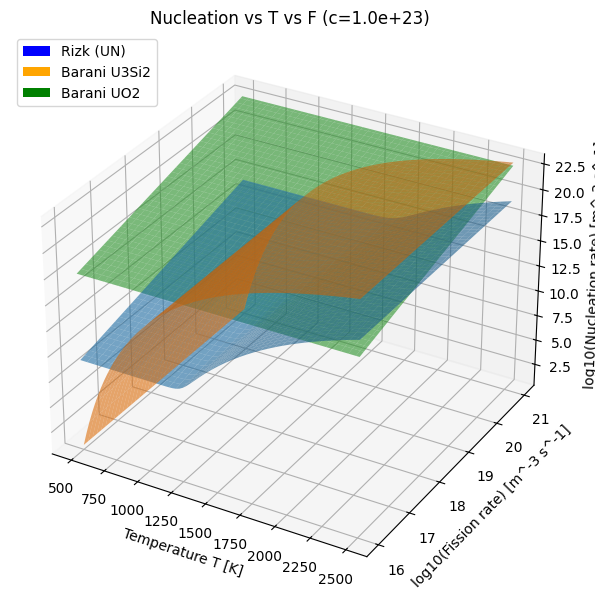

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import Patch

# =========================
# Parametri fissati
# =========================

c = 1e23   # [atomi/m^3]

# Range
T = np.linspace(500, 2500, 80)
F = np.logspace(16, 21, 80)

T_grid, F_grid = np.meshgrid(T, F)
F_log = np.log10(F_grid)
# =========================
# 1. Rizk (UN)
# =========================

kB_eV = 8.617e-5

D1 = 1.56e-3 * np.exp(-4.94 / (kB_eV * T_grid))
D3 = 1.85e-39 * F_grid
D_g = D1 + D3

f_n_rizk = 1e-6
Omega_fg = 8.5e-29

nu_rizk = 8 * np.pi * f_n_rizk * D_g * (Omega_fg)**(1/3) * c**2

# =========================
# 2. Barani (U3Si2)
# =========================

kB_J = 1.38e-23

D_barani = 5.91e-6 * np.exp(-4.41e-19 / (kB_J * T_grid))

f_n_barani = 1e-4
R_sg = 2.41e-10

nu_barani_si = 8 * np.pi * D_barani * R_sg * f_n_barani * c**2

# =========================
# 3. Barani (UO2)
# =========================

h = 25

nu_barani_uo2 = 2 * h * F_grid

# =========================
# LOG10 scala Z
# =========================

nu_rizk_log = np.log10(nu_rizk)
nu_barani_si_log = np.log10(nu_barani_si)
nu_barani_uo2_log = np.log10(nu_barani_uo2)

# =========================
# Plot 3D
# =========================

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

# superfici
surf1 = ax.plot_surface(T_grid, F_log, nu_rizk_log, alpha=0.6)
surf2 = ax.plot_surface(T_grid, F_log, nu_barani_si_log, alpha=0.6)
surf3 = ax.plot_surface(T_grid, F_log, nu_barani_uo2_log, alpha=0.6)

# etichette
ax.set_xlabel('Temperature T [K]')
ax.set_ylabel('log10(Fission rate) [m^-3 s^-1]')
ax.set_zlabel('log10(Nucleation rate) [m^-3 s^-1]')

ax.set_title(f'Nucleation vs T vs F (c={c:.1e})')

# migliora spazio per etichetta Z
plt.subplots_adjust(left=0.05, right=0.85, bottom=0.1, top=0.9)

# =========================
# Legenda (proxy)
# =========================

legend_elements = [
    Patch(facecolor='blue', label='Rizk (UN)'),
    Patch(facecolor='orange', label='Barani U3Si2'),
    Patch(facecolor='green', label='Barani UO2')
]

ax.legend(handles=legend_elements, loc='upper left')

plt.show()

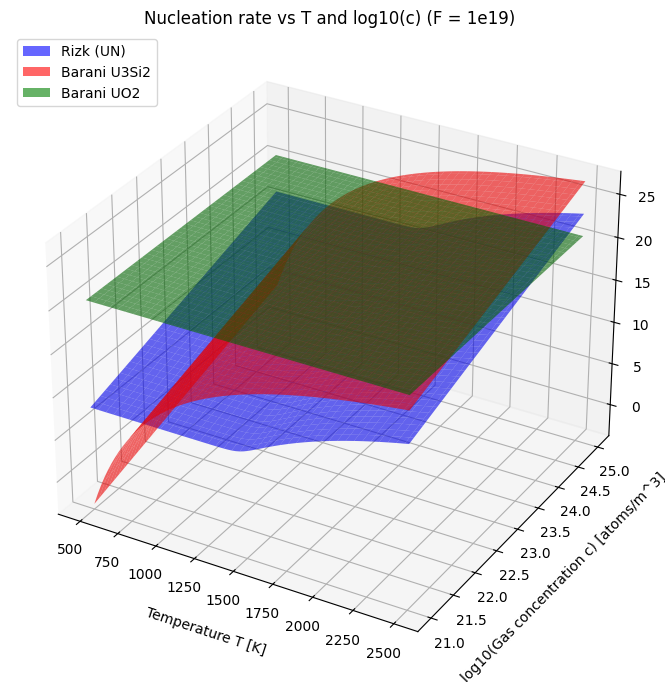

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from mpl_toolkits.mplot3d import Axes3D

# =========================
# Range variabili
# =========================

T = np.linspace(500, 2500, 80)                 # [K]
c = np.logspace(21, 25, 80)                    # [atomi/m^3]

T_grid, c_grid = np.meshgrid(T, c)

# 👉 asse log esplicito
c_log = np.log10(c_grid)

# Parametro fissato
F = 1e19   # [m^-3 s^-1]

# =========================
# 1. Rizk (UN)
# =========================

kB_eV = 8.617e-5

D1 = 1.56e-3 * np.exp(-4.94 / (kB_eV * T_grid))
D3 = 1.85e-39 * F
D_g = D1 + D3

f_n_rizk = 1e-6
Omega_fg = 8.5e-29

nu_rizk = 8 * np.pi * f_n_rizk * D_g * (Omega_fg)**(1/3) * c_grid**2

# =========================
# 2. Barani (U3Si2)
# =========================

kB_J = 1.38e-23

D_barani = 5.91e-6 * np.exp(-4.41e-19 / (kB_J * T_grid))

f_n_barani = 1e-4
R_sg = 2.41e-10

nu_barani_si = 8 * np.pi * D_barani * R_sg * f_n_barani * c_grid**2

# =========================
# 3. Barani (UO2)
# =========================

h = 25
nu_barani_uo2 = np.full_like(T_grid, h * 2 * F)

# =========================
# LOG10 asse Z
# =========================

nu_rizk_log = np.log10(nu_rizk)
nu_barani_si_log = np.log10(nu_barani_si)
nu_barani_uo2_log = np.log10(nu_barani_uo2)

# =========================
# Plot 3D
# =========================

fig = plt.figure(figsize=(11,8))
ax = fig.add_subplot(111, projection='3d')

# 👉 colori UNIFORMI (non colormap!)
surf1 = ax.plot_surface(T_grid, c_log, nu_rizk_log,
                        alpha=0.6, color='blue')

surf2 = ax.plot_surface(T_grid, c_log, nu_barani_si_log,
                        alpha=0.6, color='red')

surf3 = ax.plot_surface(T_grid, c_log, nu_barani_uo2_log,
                        alpha=0.6, color='green')

# Assi
ax.set_xlabel('Temperature T [K]', labelpad=10)
ax.set_ylabel('log10(Gas concentration c) [atoms/m^3]', labelpad=10)
ax.set_zlabel('log10(Nucleation rate) [m^-3 s^-1]', labelpad=15)

ax.set_title('Nucleation rate vs T and log10(c) (F = 1e19)')

# =========================
# Legenda coerente
# =========================

legend_elements = [
    Patch(facecolor='blue', label='Rizk (UN)', alpha=0.6),
    Patch(facecolor='red', label='Barani U3Si2', alpha=0.6),
    Patch(facecolor='green', label='Barani UO2', alpha=0.6),
]

ax.legend(handles=legend_elements, loc='upper left')

# Layout
plt.subplots_adjust(left=0.05, right=0.85, bottom=0.1, top=0.9)

plt.show()